In [359]:
import os
import pandas as pd
import sodapy as Socrata
#from dotenv import load_dotenv

In [360]:
import datetime
#date is used as start date to start pulling in data
foy=datetime.datetime(2008,1,1,0,0).strftime('%Y-%m-%dT%H:%M:%S')

In [361]:
#!/usr/bin/env python

# make sure to install these packages before running:
# pip install pandas
# pip install sodapy

import pandas as pd
from sodapy import Socrata

# Unauthenticated client only works with public data sets. Note 'None'
# in place of application token, and no username or password:
#client = Socrata("data.cityofchicago.org", None)

# Example authenticated client (needed for non-public datasets):
#plug in your App Token, you need a Chicago Data Portal. Itll be under 'Developer Settings'
client = Socrata('data.cityofchicago.org',
                'OAtaZgqYsVBUqhl9a1bqe3Pzy',
                  username="username",
                  password="password")

# for limit, I used a large # and amde sure it included start to Dec 2025 data
#the key can be found in API documentation on portal  
results = client.get("t2rn-p8d7", limit=600000000000000, where=f"month_beginning>='{foy}'")

# Convert to pandas DataFrame
results_df = pd.DataFrame.from_records(results)

In [362]:
results_df.head()

,station_id,stationame,month_beginning,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides,monthtotal
0,40900,Howard,2008-01-01T00:00:00.000,5455.5,3572.3,2476,146691
1,41190,Jarvis,2008-01-01T00:00:00.000,1391.5,994.8,747.8,38330
2,40100,Morse,2008-01-01T00:00:00.000,3764.5,2555.8,1892.2,102504
3,41300,Loyola,2008-01-01T00:00:00.000,4357.1,2972.3,2116.6,118328
4,40760,Granville,2008-01-01T00:00:00.000,3060.5,2277.8,1596.2,84424


In [363]:
results_df.dtypes

station_id                  object
stationame                  object
month_beginning             object
avg_weekday_rides           object
avg_saturday_rides          object
avg_sunday_holiday_rides    object
monthtotal                  object
dtype: object

In [364]:
#get max date
#results_df['month_beginning'].max()

In [365]:
#print out if station_id is in one of the Orange Line map_id(s)
#In this project I looked at the CTA Orange Line so I used the dataset in 'CTA - System Information - List of 'L' Stops'

# and used this code to find the target list:
#get subset of orange line stations
#orange_stations=results_df[results_df['o']==True]
#orange_stations['map_id'].unique()

#The list of values to check for
orange_target_list =['40120', '40680', '41060', '40380', '41130', '40850', '41150',
       '40160', '40930', '40960', '40040', '41400', '40260', '41700',
       '40730', '40310']

# Filter the DataFrame
orange_filtered_df = results_df[results_df['station_id'].isin(orange_target_list)].copy()
orange_filtered_df

,station_id,stationame,month_beginning,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides,monthtotal
24,41400,Roosevelt,2008-01-01T00:00:00.000,7427,5143,3872.8,203331
126,40930,Midway Airport,2008-01-01T00:00:00.000,7870.2,3129,2741.8,199370
127,40960,Pulaski-Orange,2008-01-01T00:00:00.000,4826,1572.8,896.2,116945
128,41150,Kedzie-Midway,2008-01-01T00:00:00.000,2843.4,1222.5,748.6,71188
129,40310,Western-Orange,2008-01-01T00:00:00.000,3182.6,1283.5,813,79217
...,...,...,...,...,...,...,...
30717,40850,Library,2025-11-01T00:00:00.000,2315.8,1319.6,935.7,56212
30718,40680,Adams/Wabash,2025-11-01T00:00:00.000,4475.9,2285.8,1796.2,107249
30719,41700,Washington/Wabash,2025-11-01T00:00:00.000,6673.6,4929,3350.2,171545
30720,40260,State/Lake,2025-11-01T00:00:00.000,7368.7,6222.4,3931.5,194706


### Visuals

In [366]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [367]:
#is column orange_filtered_df in datetime format?
#orange_filtered_df.dtypes

In [368]:
#load and prepare data
# Assuming 'df' is your DataFrame with a 'Date' and 'Value' column
orange_filtered_df['Date'] = pd.to_datetime(orange_filtered_df['month_beginning']) # Convert to datetime
orange_filtered_df['Year'] = orange_filtered_df['Date'].dt.year# Extract the year
orange_filtered_df['Month'] = orange_filtered_df['Date'].dt.month # Extract abbreviated month name (Jan, Feb, etc.)

#aggrgate data
# Group by year and month, then calculate the mean (or sum, etc.)
monthly_data = orange_filtered_df.groupby(['Year', 'Month']).mean().reset_index()
#QUESTION: doi really want the mean or teh sum

/var/folders/cm/k4zmvg0s1rn25xfmwj_y7ljw0000gn/T/ipykernel_5787/4012941750.py:9: FutureWarning: Dropping invalid columns in DataFrameGroupBy.mean is deprecated. In a future version, a TypeError will be raised. Before calling .mean, select only columns which should be valid for the function.
  monthly_data = orange_filtered_df.groupby(['Year', 'Month']).mean().reset_index()


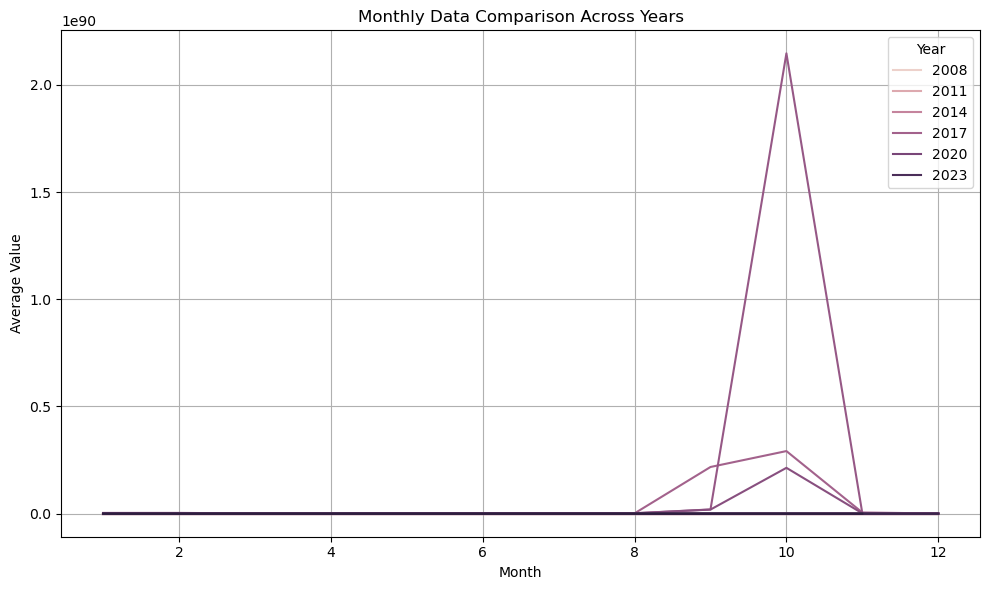

In [369]:
#Plot the Data
plt.figure(figsize=(10, 6))

# Plot the data using seaborn
#since no column of yearly exists.. whatdo i instead of monthtotal
sns.lineplot(data=monthly_data, x='Month', y='monthtotal', hue='Year') # 'hue' automatically colors by year

# Add labels and a title
plt.title('Monthly Data Comparison Across Years')
plt.xlabel('Month')
plt.ylabel('Average Value')



# Improve layout
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()








# Insight: 
Here we see that across years (2008-2025) ridership ususally spikes around fall, around Sept/Oct. 

In [370]:
#print(monthly_data.columns)

In [371]:
#plot sum of all months by year, total ridership since 2021

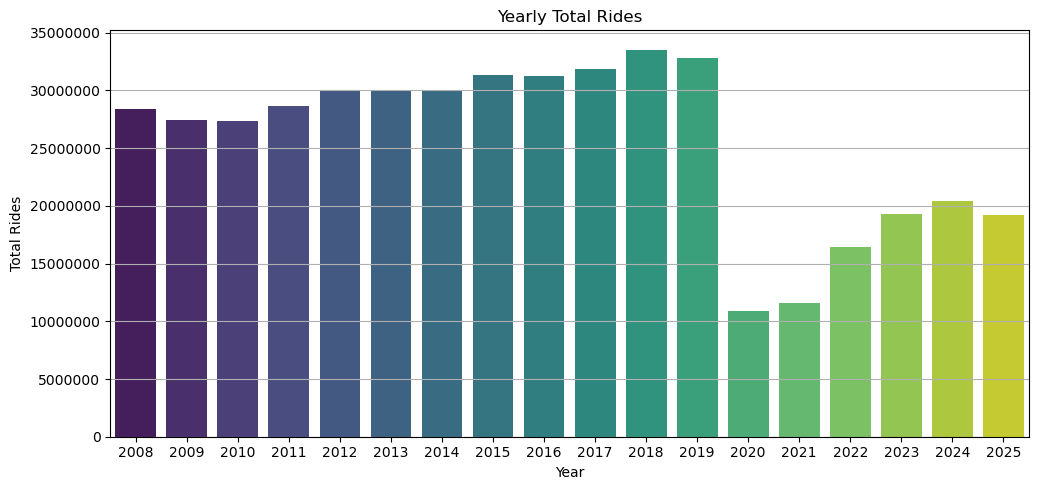

In [372]:
import pandas as pd

# Convert month_beginning to datetime
orange_filtered_df['Date'] = pd.to_datetime(orange_filtered_df['month_beginning'])

# Extract year
orange_filtered_df['Year'] = orange_filtered_df['Date'].dt.year

# Make sure monthtotal is numeric (currently it's object)
#any data that cannot be converted to the target data type will be forced to a missing value. 
orange_filtered_df['monthtotal'] = pd.to_numeric(orange_filtered_df['monthtotal'], errors='coerce')

#aggretae by year
yearly_data = orange_filtered_df.groupby('Year')['monthtotal'].sum().reset_index()

#import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(data=yearly_data, x='Year', y='monthtotal', palette='viridis')

plt.title('Yearly Total Rides')
plt.xlabel('Year')
plt.ylabel('Total Rides')
plt.grid(axis='y')
plt.tight_layout()

plt.ticklabel_format(style='plain', axis='y') # Use axis='x' if needed

plt.show()

# Insight: 
2020 saw a huge drop in ridership with a slow steady increase up until 2024. Year 2025 saw similar ridership to 2023 and higher than 2022

## Q: Did all stations experience the same shift in ridership?

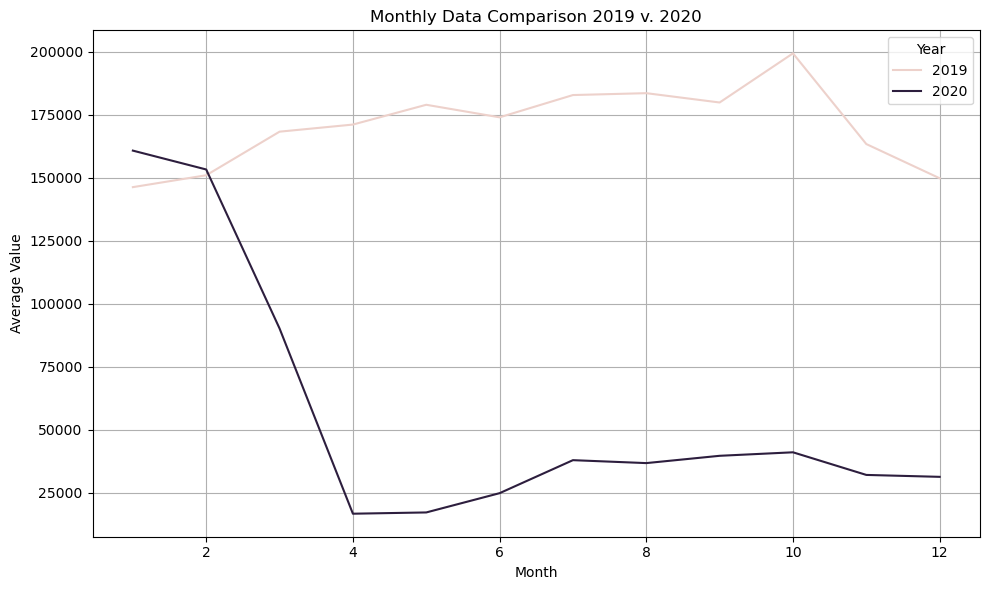

In [373]:
#lets compare ridership at the station level YoY for 2019 and 2020

#filter only these 2 years
# Filter the DataFrame
years_COVID =[2019, 2020]
orange_2019_2020= orange_filtered_df[orange_filtered_df['Year'].isin(years_COVID)].copy()

#no create a YoY or graph this dataframe


#aggrgate data
# Group by year and month, then calculate the mean (or sum, etc.)
monthly_data_COVID = orange_2019_2020.groupby(['Year', 'Month']).mean().reset_index()
#QUESTION: doi really want the mean or teh sum

#Plot the Data
plt.figure(figsize=(10, 6))

# Plot the data using seaborn
#since no column of yearly exists.. whatdo i instead of monthtotal
sns.lineplot(data=monthly_data_COVID, x='Month', y='monthtotal', hue='Year') # 'hue' automatically colors by year

# Add labels and a title
plt.title('Monthly Data Comparison 2019 v. 2020')
plt.xlabel('Month')
plt.ylabel('Average Value')

# Improve layout
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()


# Insight 
here we see the divergence in ridership MoM, comparing years 2019 and 2020. The divergence in public transit ridership between 2019 and 2020 highlights a massive, COVID-19-induced shift, with nationwide ridership in the U.S. dropping by roughly 50% year-over-year. 

<Figure size 2200x600 with 0 Axes>

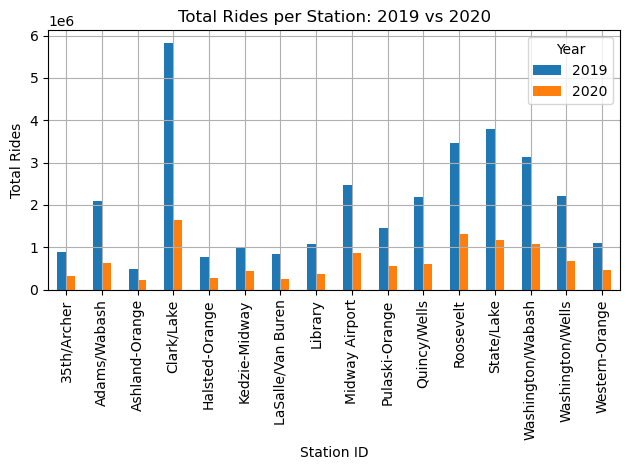

In [374]:
import matplotlib.pyplot as plt

station_year = (
    orange_2019_2020
    .groupby(["stationame", "Year"])["monthtotal"]
    .sum()
    .unstack()
)

plt.figure(figsize=(22,6))

station_year.plot(kind="bar")

plt.title("Total Rides per Station: 2019 vs 2020")
plt.xlabel("Station ID")
plt.ylabel("Total Rides")
plt.xticks(rotation=90)
plt.legend(title="Year")
plt.tight_layout()
plt.grid(True)

plt.show()

# Insight:
Here we have a bar graph of all the Orange Line stations comparing their 2019 and 2020 ridership. This graph highlights the stations that saw a larger drop in ridership. It's important to note that some stations, such as Clark/Lake are in the loop and are connected to other CTA lines, which might have contributed to the sharp drop. 

<Figure size 2200x600 with 0 Axes>

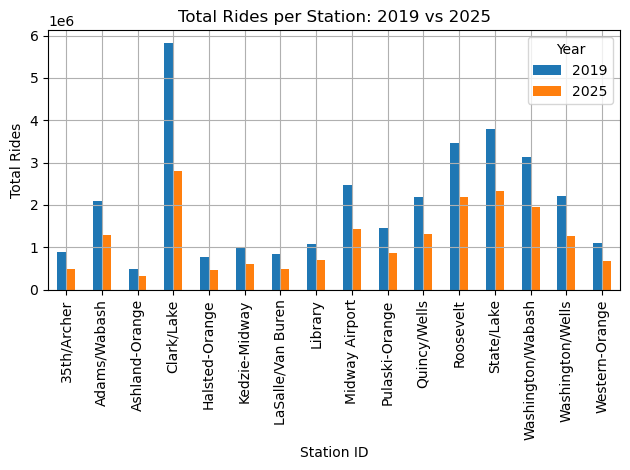

In [375]:
import matplotlib.pyplot as plt

#filter only these 2 years
# Filter the DataFrame
years_COVID_now =[2019, 2025]
orange_2019_2025= orange_filtered_df[orange_filtered_df['Year'].isin(years_COVID_now)].copy()

#no create a YoY or graph this dataframe


#aggrgate data
# Group by year and month, then calculate the mean (or sum, etc.)
monthly_data_COVID_now = orange_2019_2025.groupby(['Year', 'Month']).mean().reset_index()
#QUESTION: doi really want the mean or teh sum


station_year = (
    orange_2019_2025
    .groupby(["stationame", "Year"])["monthtotal"]
    .sum()
    .unstack()
)

plt.figure(figsize=(22,6))

station_year.plot(kind="bar")

plt.title("Total Rides per Station: 2019 vs 2025")
plt.xlabel("Station ID")
plt.ylabel("Total Rides")
plt.xticks(rotation=90)
plt.legend(title="Year")
plt.tight_layout()
plt.grid(True)

plt.show()

In [376]:
#lets compare 2019, 2020, and 2025 ridership per station
#filter only these 2 years
# Filter the DataFrame
years_2019_2020_now =[2020, 2025]
orange_2019_2020_now= orange_filtered_df[orange_filtered_df['Year'].isin(years_2019_2020_now)].copy()


Year                  2019     2020     2025
stationame                                  
35th/Archer         896292   326259   490374
Adams/Wabash       2087483   636466  1286646
Ashland-Orange      478166   221502   320064
Clark/Lake         5830767  1648674  2798412
Halsted-Orange      766196   275368   471276
Kedzie-Midway      1009589   433671   615001
LaSalle/Van Buren   830063   257786   482515
Library            1077009   376074   693587
Midway Airport     2477340   861649  1424123
Pulaski-Orange     1465594   568830   854899
Quincy/Wells       2188354   595970  1315977
Roosevelt          3466910  1313925  2197951
State/Lake         3783187  1164251  2337971
Washington/Wabash  3126070  1082287  1953774
Washington/Wells   2214522   668828  1265856
Western-Orange     1089224   466470   667905


<Figure size 2200x600 with 0 Axes>

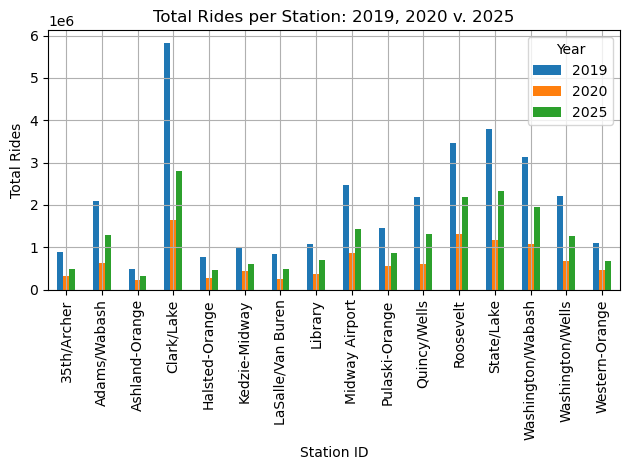

In [377]:
#lets compare 2019, 2020, and 2025 ridership per station

#filter only these 3 years
# Filter the DataFrame
years_2019_2020_2025 =[2019, 2020, 2025]
orange_2019_2020_2025= orange_filtered_df[orange_filtered_df['Year'].isin(years_2019_2020_2025)].copy()

#no create a YoY or graph this dataframe


#aggrgate data
# Group by year and month, then calculate the mean (or sum, etc.)
monthly_data_2019_2020_2025 = orange_2019_2020_2025.groupby(['Year', 'Month']).mean().reset_index()
#QUESTION: do i really want the mean or teh sum


station_year = (
    orange_2019_2020_2025
    .groupby(["stationame", "Year"])["monthtotal"]
    .sum()
    .unstack()
)

#undo
print(station_year)

plt.figure(figsize=(22,6))

station_year.plot(kind="bar")

plt.title("Total Rides per Station: 2019, 2020 v. 2025")
plt.xlabel("Station ID")
plt.ylabel("Total Rides")
plt.xticks(rotation=90)
plt.legend(title="Year")
plt.tight_layout()
plt.grid(True)

plt.show()

# Insight:
When looking at ridership for 2019, 2020, and 2025 we see that not all stations have been able to recover pre-COVID ridership numbers at the same rate.

In [378]:
# calc  % diff for 2019 v 2025 for all stations
station_year

#print out %change Df for stations
percent_diff_2019_2025=(station_year[2025]-station_year[2019])/ (station_year[2019])
percent_diff_2019_2025.sort_values( ascending=True, inplace=False)

print('Average % diff:',percent_diff_2019_2025.mean())
print(percent_diff_2019_2025.sort_values( ascending=True, inplace=False))

Average % diff: -0.4010243469298565
stationame
Clark/Lake          -0.520061
35th/Archer         -0.452886
Washington/Wells    -0.428384
Midway Airport      -0.425140
LaSalle/Van Buren   -0.418701
Pulaski-Orange      -0.416688
Quincy/Wells        -0.398645
Kedzie-Midway       -0.390840
Western-Orange      -0.386807
Halsted-Orange      -0.384915
Adams/Wabash        -0.383638
State/Lake          -0.382010
Washington/Wabash   -0.375006
Roosevelt           -0.366020
Library             -0.356006
Ashland-Orange      -0.330642
dtype: float64


# Insight
When looking at percent difference by station comapring 2019 and 2025, we see that stations have an average percent change from 2019 to 2025 of -0.4010243469298565 and 6 of these stations have lower percent change. These (6) stations seem to be struggling to get back to their pre-COVID ridership numbers. (3) of these stations are in the loop, the other (3) are not (35th/Archer, Midway Airport,Pulaski-Orange)

* Clark/Lake          -0.520061
* 35th/Archer         -0.452886
* Washington/Wells    -0.428384
* Midway Airport      -0.425140
* LaSalle/Van Buren   -0.418701
* Pulaski-Orange      -0.416688


# Q:  is their a driving factor (ridership type) for this lower recovery rate among these (6) stations? Did the relationship between ride types and total ridership change from 2020–2025?

In [379]:
orange_2019_now

,station_id,stationame,month_beginning,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides,monthtotal,Date,Year,Month
18855,41400,Roosevelt,2019-01-01T00:00:00.000,8426.8,6070.5,5279.8,236071,2019-01-01,2019,1
18960,40930,Midway Airport,2019-01-01T00:00:00.000,6677.5,2853.0,2529.8,170967,2019-01-01,2019,1
18961,40960,Pulaski-Orange,2019-01-01T00:00:00.000,4146.9,1647.0,1088.0,103259,2019-01-01,2019,1
18962,41150,Kedzie-Midway,2019-01-01T00:00:00.000,2867.5,1359.5,947.0,73259,2019-01-01,2019,1
18963,40310,Western-Orange,2019-01-01T00:00:00.000,3048.4,1460.3,1045.8,78135,2019-01-01,2019,1
...,...,...,...,...,...,...,...,...,...,...
30717,40850,Library,2025-11-01T00:00:00.000,2315.8,1319.6,935.7,56212,2025-11-01,2025,11
30718,40680,Adams/Wabash,2025-11-01T00:00:00.000,4475.9,2285.8,1796.2,107249,2025-11-01,2025,11
30719,41700,Washington/Wabash,2025-11-01T00:00:00.000,6673.6,4929.0,3350.2,171545,2025-11-01,2025,11
30720,40260,State/Lake,2025-11-01T00:00:00.000,7368.7,6222.4,3931.5,194706,2025-11-01,2025,11


In [380]:
#i think the 3 other columns arent numeric
orange_2019_now.dtypes

station_id                          object
stationame                          object
month_beginning                     object
avg_weekday_rides                  float64
avg_saturday_rides                 float64
avg_sunday_holiday_rides           float64
monthtotal                           int64
Date                        datetime64[ns]
Year                                 int64
Month                                int64
dtype: object

In [381]:
cols = ['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides']
orange_2019_now[cols] = orange_2019_now[cols].apply(pd.to_numeric, errors='coerce')
#i think the 3 other columns arent numeric
orange_2019_now.dtypes

station_id                          object
stationame                          object
month_beginning                     object
avg_weekday_rides                  float64
avg_saturday_rides                 float64
avg_sunday_holiday_rides           float64
monthtotal                           int64
Date                        datetime64[ns]
Year                                 int64
Month                                int64
dtype: object

In [382]:
orange_2019_now.groupby(['stationame','Year'])[['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides','monthtotal']].sum()

avg_weekday_rides  avg_saturday_rides  \
stationame        Year                                          
35th/Archer       2019            35890.5             17205.1   
                  2025            19058.9             10870.0   
Adams/Wabash      2019            85039.2             35010.4   
                  2025            49116.9             30424.9   
Ashland-Orange    2019            18657.4             10310.6   
                  2025            12270.2              7558.8   
Clark/Lake        2019           247227.8             70751.5   
                  2025           107934.8             62767.3   
Halsted-Orange    2019            31174.1             13138.5   
                  2025            18277.2             10294.0   
Kedzie-Midway     2019            40310.9             19720.9   
                  2025            23988.2             13389.8   
LaSalle/Van Buren 2019            36818.1              6107.0   
                  2025            20340.3              6593.2   
Library           2019            43358.6             20023.1   
                  2025            25982.9             17903.8   
Midway Airport    2019            97941.3             46662.8   
                  2025            54709.0             31589.4   
Pulaski-Orange    2019            59666.6             25333.2   
                  2025            34176.9             16281.0   
Quincy/Wells      2019            96141.6             17192.5   
                  2025            55861.0             15667.5   
Roosevelt         2019           125222.7             96712.1   
                  2025            73810.1             75325.7   
State/Lake        2019           149538.9             77343.0   
                  2025            83806.9             71410.7   
Washington/Wabash 2019           124395.4             62411.1   
                  2025            72048.9             54289.4   
Washington/Wells  2019            98897.6             14297.2   
                  2025            55304.6             11934.2   
Western-Orange    2019            43290.5             21417.3   
                  2025            26116.8             14256.1   

                        avg_sunday_holiday_rides  monthtotal  
stationame        Year                                        
35th/Archer       2019                   12231.2      896292  
                  2025                    8062.8      490374  
Adams/Wabash      2019                   26917.4     2087483  
                  2025                   23555.2     1286646  
Ashland-Orange    2019                    7691.4      478166  
                  2025                    5601.9      320064  
Clark/Lake        2019                   55471.4     5830767  
                  2025                   48532.5     2798412  
Halsted-Orange    2019                    9826.6      766196  
                  2025                    8142.4      471276  
Kedzie-Midway     2019                   14006.0     1009589  
                  2025                    9954.3      615001  
LaSalle/Van Buren 2019                    4441.2      830063  
                  2025                    4637.7      482515  
Library           2019                   14434.0     1077009  
                  2025                   13362.0      693587  
Midway Airport    2019                   39918.2     2477340  
                  2025                   25835.7     1424123  
Pulaski-Orange    2019                   18325.8     1465594  
                  2025                   12268.0      854899  
Quincy/Wells      2019                   14572.3     2188354  
                  2025                   12926.9     1315977  
Roosevelt         2019                   80405.5     3466910  
                  2025                   62586.8     2197951  
State/Lake        2019                   55626.2     3783187  
                  2025                   51123.7     2337971  
Washington/Wabash 2019                   43459.6 

In [383]:
# Make sure ride columns are numeric
ride_cols = ['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal']
orange_2019_now[ride_cols] = orange_2019_now[ride_cols].apply(pd.to_numeric, errors='coerce')
# Group and sum
station_diff = orange_2019_now.groupby(['stationame','Year'])[ride_cols].sum()

# Pivot so years are columns
station_diff = station_diff.reset_index().pivot(index='stationame', columns='Year')

# Flatten MultiIndex
station_diff.columns = [f"{col[0]}_{col[1]}" for col in station_diff.columns]

# Now all ride columns exist for 2019 and 2025
station_diff

,avg_weekday_rides_2019,avg_weekday_rides_2025,avg_saturday_rides_2019,avg_saturday_rides_2025,avg_sunday_holiday_rides_2019,avg_sunday_holiday_rides_2025,monthtotal_2019,monthtotal_2025
stationame,,,,,,,,
35th/Archer,35890.5,19058.9,17205.1,10870.0,12231.2,8062.8,896292,490374
Adams/Wabash,85039.2,49116.9,35010.4,30424.9,26917.4,23555.2,2087483,1286646
Ashland-Orange,18657.4,12270.2,10310.6,7558.8,7691.4,5601.9,478166,320064
Clark/Lake,247227.8,107934.8,70751.5,62767.3,55471.4,48532.5,5830767,2798412
Halsted-Orange,31174.1,18277.2,13138.5,10294.0,9826.6,8142.4,766196,471276
Kedzie-Midway,40310.9,23988.2,19720.9,13389.8,14006.0,9954.3,1009589,615001
LaSalle/Van Buren,36818.1,20340.3,6107.0,6593.2,4441.2,4637.7,830063,482515
Library,43358.6,25982.9,20023.1,17903.8,14434.0,13362.0,1077009,693587
Midway Airport,97941.3,54709.0,46662.8,31589.4,39918.2,25835.7,2477340,1424123


In [384]:
station_diff['weekday_2019_%']= (station_diff['avg_weekday_rides_2019'])/(station_diff['avg_weekday_rides_2019']+station_diff['avg_saturday_rides_2019']+station_diff['avg_sunday_holiday_rides_2019'])
station_diff['saturday_2019_%']=(station_diff['avg_saturday_rides_2019'])/(station_diff['avg_weekday_rides_2019']+station_diff['avg_saturday_rides_2019']+station_diff['avg_sunday_holiday_rides_2019'])
station_diff['sunday_2019_%']=(station_diff['avg_sunday_holiday_rides_2019'])/(station_diff['avg_weekday_rides_2019']+station_diff['avg_saturday_rides_2019']+station_diff['avg_sunday_holiday_rides_2019'])

station_diff['weekday_2025_%']= (station_diff['avg_weekday_rides_2025'])/(station_diff['avg_weekday_rides_2025']+station_diff['avg_saturday_rides_2025']+station_diff['avg_sunday_holiday_rides_2025'])
station_diff['saturday_2025_%']=(station_diff['avg_saturday_rides_2025'])/(station_diff['avg_weekday_rides_2025']+station_diff['avg_saturday_rides_2025']+station_diff['avg_sunday_holiday_rides_2025'])
station_diff['sunday_2025_%']=(station_diff['avg_sunday_holiday_rides_2025'])/(station_diff['avg_weekday_rides_2025']+station_diff['avg_saturday_rides_2025']+station_diff['avg_sunday_holiday_rides_2025'])

# Create a new DataFrame with only the selected columns, ensuring it's a deep copy
station_diff_comparison= station_diff[['weekday_2019_%','saturday_2019_%','sunday_2019_%','weekday_2025_%','saturday_2025_%', 'sunday_2025_%']].copy()


In [385]:
# create diff columns and sort..station_diff_comparison
station_diff_comparison['%_diff_weekday']=station_diff_comparison['weekday_2025_%']-station_diff_comparison['weekday_2019_%']
station_diff_comparison['%_diff_saturday']=station_diff_comparison['saturday_2025_%']-station_diff_comparison['saturday_2019_%']
station_diff_comparison['%_diff_sunday']=station_diff_comparison['sunday_2025_%']-station_diff_comparison['sunday_2019_%']


In [386]:
# Sort by '_diff_weekday' in ascending order
sorted_station_diff_comparison = station_diff_comparison.sort_values(by='%_diff_weekday')
sorted_station_diff_comparison


,weekday_2019_%,saturday_2019_%,sunday_2019_%,weekday_2025_%,saturday_2025_%,sunday_2025_%,%_diff_weekday,%_diff_saturday,%_diff_sunday
stationame,,,,,,,,,
Clark/Lake,0.662009,0.189453,0.148537,0.492326,0.286302,0.221372,-0.169684,0.096849,0.072835
LaSalle/Van Buren,0.777306,0.128931,0.093763,0.644268,0.208836,0.146897,-0.133038,0.079905,0.053134
State/Lake,0.529326,0.273773,0.196901,0.406157,0.346080,0.247763,-0.123169,0.072308,0.050862
Washington/Wabash,0.540225,0.271039,0.188736,0.436002,0.328531,0.235468,-0.104223,0.057492,0.046731
Library,0.557196,0.257314,0.185490,0.453860,0.312737,0.233403,-0.103336,0.055423,0.047913
Adams/Wabash,0.578628,0.238219,0.183153,0.476414,0.295109,0.228476,-0.102213,0.056890,0.045323
Quincy/Wells,0.751656,0.134415,0.113929,0.661426,0.185512,0.153062,-0.090230,0.051097,0.039132
Halsted-Orange,0.575814,0.242680,0.181506,0.497832,0.280387,0.221782,-0.077982,0.037707,0.040275
Washington/Wells,0.798908,0.115495,0.085597,0.729941,0.157514,0.112544,-0.068967,0.042020,0.026947


In [387]:
# Sort by '%_diff_saturday' in ascending order
sorted_station_diff_comparison = station_diff_comparison.sort_values(by='%_diff_saturday')
sorted_station_diff_comparison

,weekday_2019_%,saturday_2019_%,sunday_2019_%,weekday_2025_%,saturday_2025_%,sunday_2025_%,%_diff_weekday,%_diff_saturday,%_diff_sunday
stationame,,,,,,,,,
Western-Orange,0.537536,0.265938,0.196526,0.510676,0.278757,0.210566,-0.026860,0.012820,0.014041
Pulaski-Orange,0.577462,0.245178,0.177360,0.544861,0.259558,0.195581,-0.032601,0.014380,0.018221
Ashland-Orange,0.508939,0.281254,0.209807,0.482492,0.297229,0.220279,-0.026447,0.015975,0.010472
Kedzie-Midway,0.544464,0.266363,0.189174,0.506804,0.282889,0.210307,-0.037660,0.016527,0.021133
35th/Archer,0.549399,0.263370,0.187231,0.501660,0.286115,0.212225,-0.047740,0.022745,0.024994
Midway Airport,0.530783,0.252884,0.216333,0.487889,0.281711,0.230400,-0.042894,0.028827,0.014067
Roosevelt,0.414178,0.319878,0.265944,0.348617,0.355775,0.295608,-0.065561,0.035897,0.029664
Halsted-Orange,0.575814,0.242680,0.181506,0.497832,0.280387,0.221782,-0.077982,0.037707,0.040275
Washington/Wells,0.798908,0.115495,0.085597,0.729941,0.157514,0.112544,-0.068967,0.042020,0.026947


In [388]:
# Sort by '%_diff_saturday' in ascending order
sorted_station_diff_comparison = station_diff_comparison.sort_values(by='%_diff_sunday')
sorted_station_diff_comparison

,weekday_2019_%,saturday_2019_%,sunday_2019_%,weekday_2025_%,saturday_2025_%,sunday_2025_%,%_diff_weekday,%_diff_saturday,%_diff_sunday
stationame,,,,,,,,,
Ashland-Orange,0.508939,0.281254,0.209807,0.482492,0.297229,0.220279,-0.026447,0.015975,0.010472
Western-Orange,0.537536,0.265938,0.196526,0.510676,0.278757,0.210566,-0.026860,0.012820,0.014041
Midway Airport,0.530783,0.252884,0.216333,0.487889,0.281711,0.230400,-0.042894,0.028827,0.014067
Pulaski-Orange,0.577462,0.245178,0.177360,0.544861,0.259558,0.195581,-0.032601,0.014380,0.018221
Kedzie-Midway,0.544464,0.266363,0.189174,0.506804,0.282889,0.210307,-0.037660,0.016527,0.021133
35th/Archer,0.549399,0.263370,0.187231,0.501660,0.286115,0.212225,-0.047740,0.022745,0.024994
Washington/Wells,0.798908,0.115495,0.085597,0.729941,0.157514,0.112544,-0.068967,0.042020,0.026947
Roosevelt,0.414178,0.319878,0.265944,0.348617,0.355775,0.295608,-0.065561,0.035897,0.029664
Quincy/Wells,0.751656,0.134415,0.113929,0.661426,0.185512,0.153062,-0.090230,0.051097,0.039132


# Insight:
Stations 
* Clark/Lake was mainly driven by a drop in weekday rides(largest shift)
* 35th/Archer was mainly driven by a drop in weekday rides 
* Washington/Wells mainly driven by a drop in weekday rides 
* Midway Airport mainly driven by a drop in weekday rides 
* LaSalle/Van Buren mainly driven by a drop in weekday rides 
* Pulaski-Orange mainly driven by a drop in weekday rides 


## Can we segment transit stations based on usage patterns to better allocate resources?

In [389]:
#make sure features are numeric
cols = ['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides']
years_post_COVID_df[cols] = years_post_COVID_df[cols].apply(pd.to_numeric, errors='coerce')
#i think the 3 other columns arent numeric
years_post_COVID_df.dtypes


station_id                          object
stationame                          object
month_beginning                     object
avg_weekday_rides                  float64
avg_saturday_rides                 float64
avg_sunday_holiday_rides           float64
monthtotal                           int64
Date                        datetime64[ns]
Year                                 int64
Month                                int64
dtype: object

In [390]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

features = [
    "avg_weekday_rides",
    "avg_saturday_rides",
    "avg_sunday_holiday_rides"
]

# Aggregate to one row per station
station_features = (
    years_post_COVID_df
    .groupby("stationame")[features]
    .mean()
)

#Now each station has 3 behavioral features

#scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(station_features)


inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(12,6))  # width=12, height=6


#fit kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
station_features["Cluster"] = kmeans.fit_predict(scaled_data)

station_features.head()

,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides,Cluster
stationame,,,,
35th/Archer,1493.953521,826.484507,613.914085,0
Adams/Wabash,3415.064789,2018.195775,1593.476056,2
Ashland-Orange,957.660563,586.777465,442.491549,0
Clark/Lake,7410.771831,3977.953521,3187.325352,1
Halsted-Orange,1341.807042,745.154930,571.594366,0


<Figure size 1200x600 with 0 Axes>

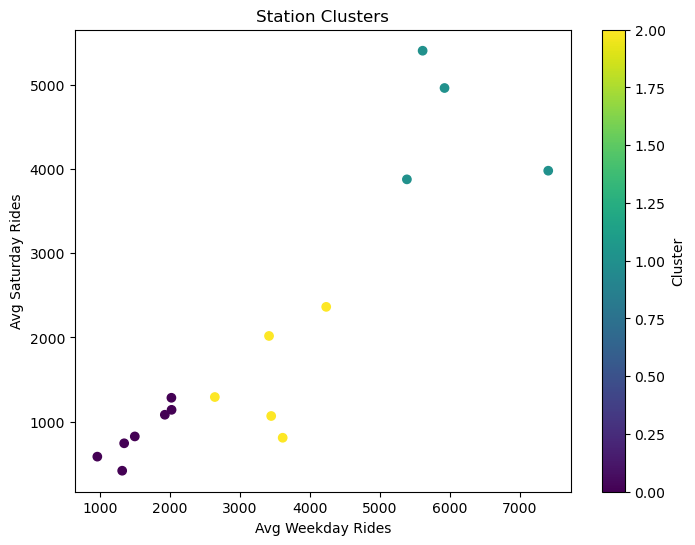

In [391]:
#visialize 
plt.figure(figsize=(8,6))

plt.scatter(
    station_features["avg_weekday_rides"],
    station_features["avg_saturday_rides"],
    c=station_features["Cluster"],
    cmap="viridis"
)

plt.xlabel("Avg Weekday Rides")
plt.ylabel("Avg Saturday Rides")
plt.title("Station Clusters")
plt.colorbar(label="Cluster")
plt.show()


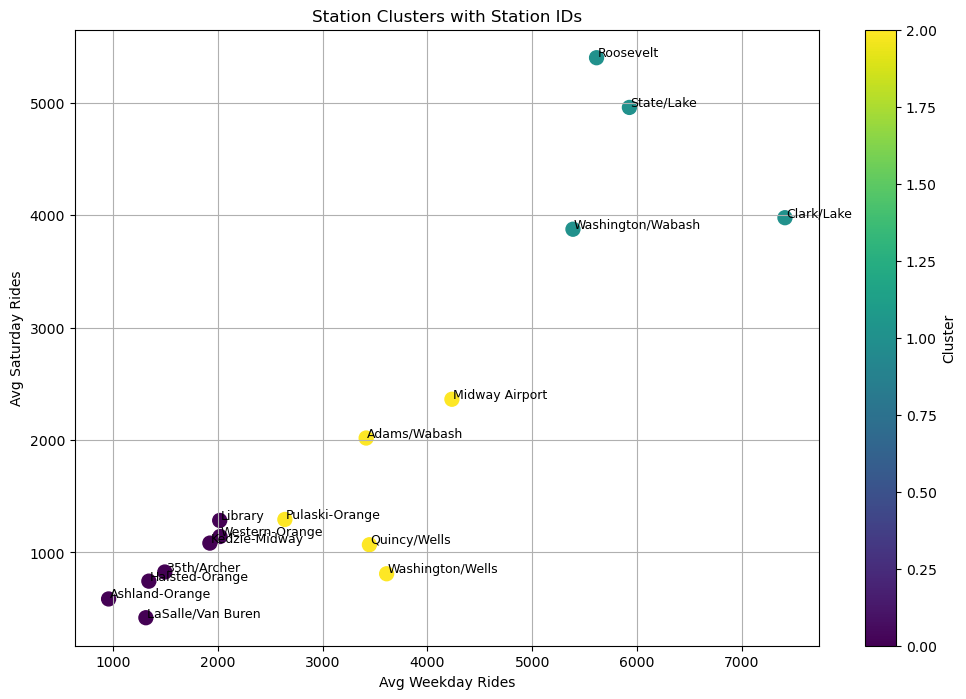

In [392]:
plt.figure(figsize=(12,8))

# Scatter plot
plt.scatter(
    station_features["avg_weekday_rides"],
    station_features["avg_saturday_rides"],
    c=station_features["Cluster"],
    cmap="viridis",
    s=100  # size of the points
)

# Add labels for each station
for i, stationame in enumerate(station_features.index):
    plt.text(
        station_features["avg_weekday_rides"].iloc[i] + 10,  # small offset to avoid overlap
        station_features["avg_saturday_rides"].iloc[i] + 10,
        str(stationame),
        fontsize=9
    )

plt.xlabel("Avg Weekday Rides")
plt.ylabel("Avg Saturday Rides")
plt.title("Station Clusters with Station IDs")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

In [393]:
#interpert clsuters 
station_features.groupby("Cluster").mean()

,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides
Cluster,,,
0,1581.250905,869.822334,650.171429
1,6084.677113,4553.313732,3506.784155
2,3468.851831,1510.988169,1207.648732


# PART 2

In [422]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select features
features = years_post_COVID_df[['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal']]

# Aggregate per station 
station_features = features.groupby(years_post_COVID_df['station_id']).mean()

# Standardize features
scaler = StandardScaler()
station_features_scaled = scaler.fit_transform(station_features)



In [414]:
features

,avg_weekday_rides,avg_saturday_rides,avg_sunday_holiday_rides,monthtotal
20572,9408.3,6195.8,4588.6,254709
20677,7104.0,2728.5,2311.6,178760
20678,4775.5,1554.3,1123.2,116895
20679,3138.7,1259.0,906.6,78621
20680,3417.2,1404.5,1049.2,86043
...,...,...,...,...
30717,2315.8,1319.6,935.7,56212
30718,4475.9,2285.8,1796.2,107249
30719,6673.6,4929.0,3350.2,171545
30720,7368.7,6222.4,3931.5,194706


In [423]:
print("Stations:", station_features.shape[0])
print("Means:\n", station_features.mean())
print("Std:\n", station_features.std())

Stations: 16
Means:
 avg_weekday_rides            3296.982746
avg_saturday_rides           1991.059507
avg_sunday_holiday_rides     1538.536268
monthtotal                  86179.781690
dtype: float64
Std:
 avg_weekday_rides            1943.394990
avg_saturday_rides           1636.971281
avg_sunday_holiday_rides     1274.783196
monthtotal                  53490.775021
dtype: float64


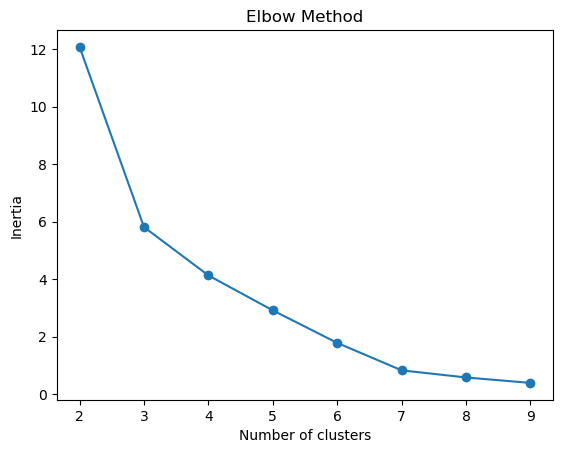

k=2, silhouette score=0.703
k=3, silhouette score=0.538
k=4, silhouette score=0.506
k=5, silhouette score=0.420
k=6, silhouette score=0.440
k=7, silhouette score=0.487
k=8, silhouette score=0.435
k=9, silhouette score=0.371


In [395]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Elbow method: The bend (elbow) is the optimal number of clusters.
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(station_features_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Optional: silhouette score
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(station_features_scaled)
    score = silhouette_score(station_features_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

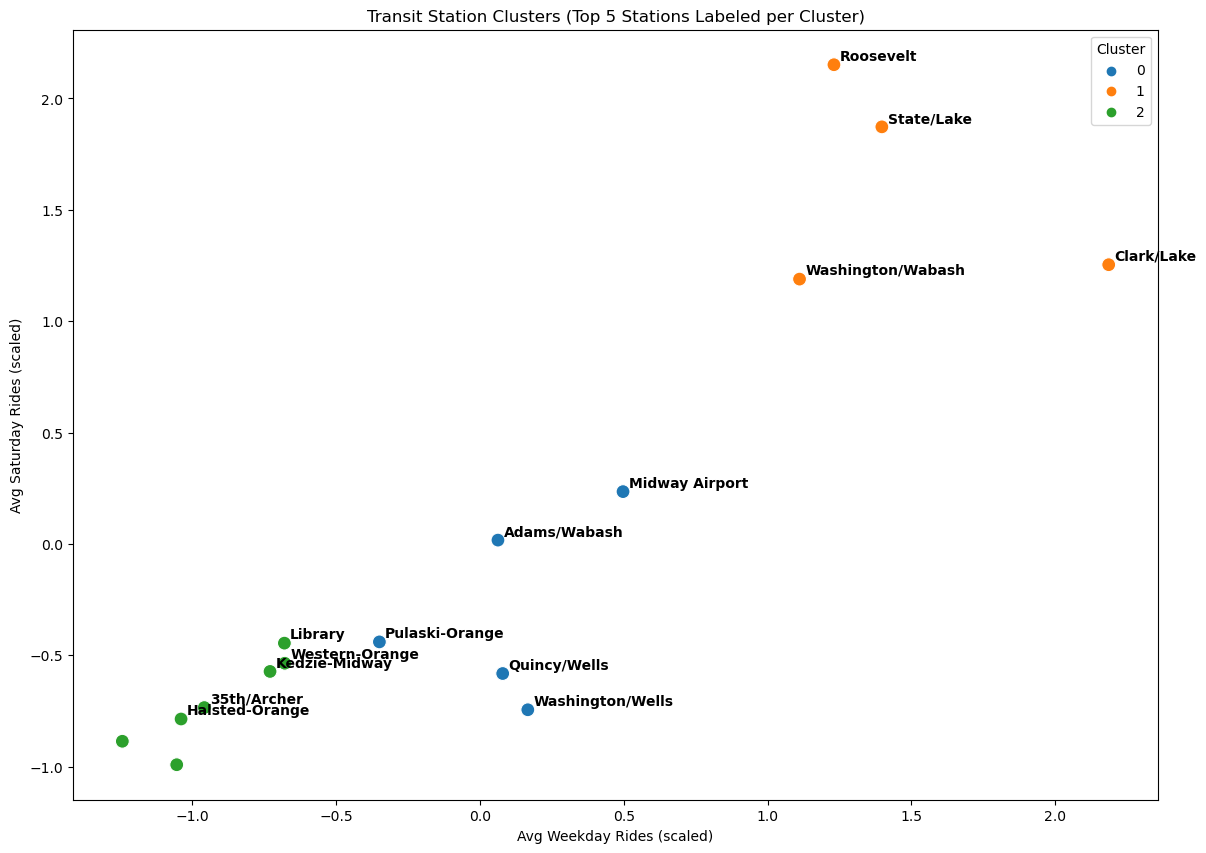

In [430]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Step 1: Aggregate features per station ---
station_features_numeric = years_post_COVID_df.groupby('station_id')[[
    'avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal'
]].mean()

station_names = years_post_COVID_df.groupby('station_id')['stationame'].first()
station_features = station_features_numeric.join(station_names)

# --- Step 2: Scale numeric features ---
scaler = StandardScaler()
station_features_scaled = scaler.fit_transform(station_features[['avg_weekday_rides',
                                                                 'avg_saturday_rides',
                                                                 'avg_sunday_holiday_rides',
                                                                 'monthtotal']])

# --- Step 3: K-means clustering ---
k = 3  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
station_features['cluster'] = kmeans.fit_predict(station_features_scaled)

# --- Step 4: Prepare DataFrame for plotting ---
plot_df = pd.DataFrame(station_features_scaled,
                       columns=['weekday_scaled', 'saturday_scaled', 'sunday_scaled', 'monthtotal_scaled'],
                       index=station_features.index)
plot_df['cluster'] = station_features['cluster'].values
plot_df['stationame'] = station_features['stationame'].values
plot_df['monthtotal'] = station_features['monthtotal'].values  # for filtering top stations

# --- Step 5: Plot scatter ---
plt.figure(figsize=(14,10))
sns.scatterplot(
    x='weekday_scaled',
    y='saturday_scaled',
    hue='cluster',
    palette='tab10',
    data=plot_df,
    s=100
)

# --- Step 6: Label top N busiest stations per cluster ---
top_n = 5  # number of stations to label per cluster
for cluster in plot_df['cluster'].unique():
    cluster_df = plot_df[plot_df['cluster'] == cluster]
    top_stations = cluster_df.nlargest(top_n, 'monthtotal')
    for i in top_stations.index:
        plt.text(
            x=top_stations.loc[i, 'weekday_scaled'] + 0.02,
            y=top_stations.loc[i, 'saturday_scaled'] + 0.02,
            s=top_stations.loc[i, 'stationame'],
            fontsize=10,
            fontweight='bold'
        )

plt.xlabel('Avg Weekday Rides (scaled)')
plt.ylabel('Avg Saturday Rides (scaled)')
plt.title(f'Transit Station Clusters (Top {top_n} Stations Labeled per Cluster)')
plt.legend(title='Cluster')
plt.show()

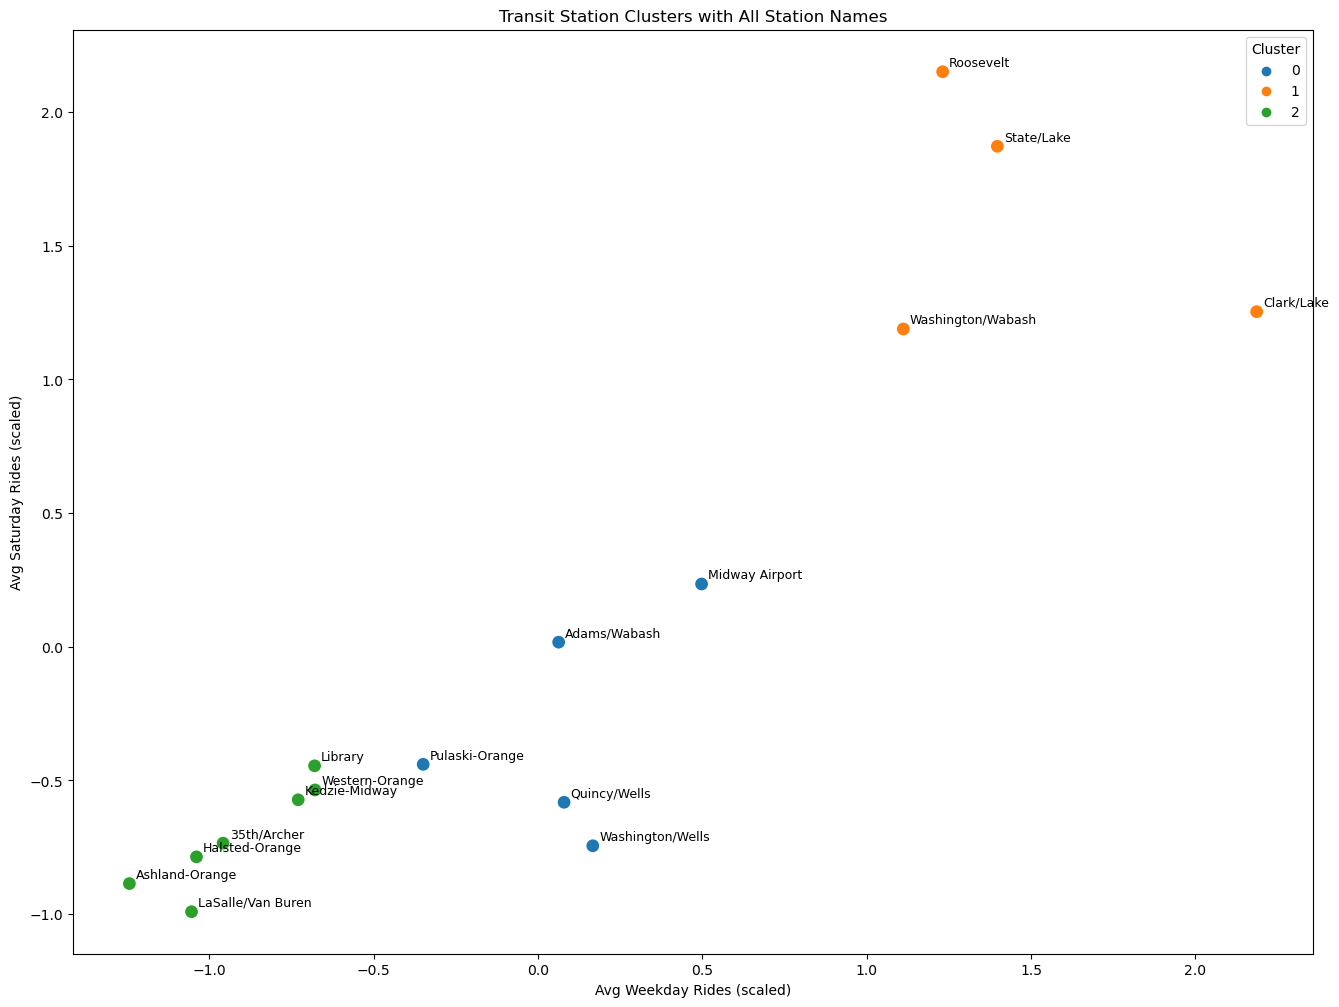

In [400]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Step 1: Aggregate features per station ---
station_features_numeric = years_post_COVID_df.groupby('station_id')[[
    'avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal'
]].mean()

station_names = years_post_COVID_df.groupby('station_id')['stationame'].first()
station_features = station_features_numeric.join(station_names)

# --- Step 2: Scale numeric features ---
scaler = StandardScaler()
station_features_scaled = scaler.fit_transform(station_features[['avg_weekday_rides',
                                                                 'avg_saturday_rides',
                                                                 'avg_sunday_holiday_rides',
                                                                 'monthtotal']])

# --- Step 3: K-means clustering ---
k = 3  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
station_features['cluster'] = kmeans.fit_predict(station_features_scaled)

# --- Step 4: Prepare DataFrame for plotting ---
plot_df = pd.DataFrame(station_features_scaled,
                       columns=['weekday_scaled', 'saturday_scaled', 'sunday_scaled', 'monthtotal_scaled'],
                       index=station_features.index)
plot_df['cluster'] = station_features['cluster'].values
plot_df['stationame'] = station_features['stationame'].values

# --- Step 5: Scatter plot ---
plt.figure(figsize=(16,12))
sns.scatterplot(
    x='weekday_scaled',
    y='saturday_scaled',
    hue='cluster',
    palette='tab10',
    data=plot_df,
    s=100
)

# --- Step 6: Label all stations ---
for i in range(plot_df.shape[0]):
    plt.text(
        x=plot_df['weekday_scaled'].iloc[i] + 0.02,
        y=plot_df['saturday_scaled'].iloc[i] + 0.02,
        s=plot_df['stationame'].iloc[i],
        fontsize=9
    )

plt.xlabel('Avg Weekday Rides (scaled)')
plt.ylabel('Avg Saturday Rides (scaled)')
plt.title('Transit Station Clusters with All Station Names')
plt.legend(title='Cluster')
plt.show()

In [401]:
import pandas as pd
import numpy as np

# Assume station_features already has numeric columns and 'cluster' assigned

# --- Step 1: Compute average rides per cluster ---
cluster_summary = station_features.groupby('cluster').agg({
    'avg_weekday_rides': 'mean',
    'avg_saturday_rides': 'mean',
    'avg_sunday_holiday_rides': 'mean',
    'monthtotal': ['mean', 'sum'],  # mean per station and total for cluster
    'stationame': 'count'  # number of stations per cluster
})

# Rename columns for readability
cluster_summary.columns = ['weekday_avg', 'saturday_avg', 'sunday_avg', 'monthtotal_avg', 'monthtotal_sum', 'num_stations']
cluster_summary = cluster_summary.reset_index()

cluster_summary

,cluster,weekday_avg,saturday_avg,sunday_avg,monthtotal_avg,monthtotal_sum,num_stations
0,0,3468.851831,1510.988169,1207.648732,86128.676056,430643.380282,5
1,1,6084.677113,4553.313732,3506.784155,166145.598592,664582.394366,4
2,2,1581.250905,869.822334,650.171429,40521.533199,283650.732394,7






If I were allocating staff, trains, or maintenance resources, would I treat these clusters differently?

If yes → your clustering is meaningful.

So we clearly have:

Cluster 1 → Very high-volume stations

Cluster 0 → Mid-volume stations

Cluster 2 → Low-volume stations

# Compare Usage Patterns (Weekday vs Weekend)
Cluster 0

Weekday much higher than weekend

Weekday ≈ 2.3× Saturday
Strong commuter pattern

Cluster 1

High weekday

Very strong weekend activity too

Weekend ridership relatively large

This suggests:
These are major hubs / destination stations

Cluster 2

Low across all days

Still weekday dominant

Likely:
Smaller neighborhood or peripheral stations

## Final Interpretation of Each Cluster
* Cluster 1 — Major Hubs (4 stations)

Extremely high total ridership

Strong weekday AND strong weekend traffic

Likely downtown, transfer, airport, entertainment centers

Resource priority: highest staffing, security, maintenance

* Cluster 0 — Commuter-Dominant Stations (5 stations)

High weekday traffic

Moderate weekend traffic

Likely residential → business district commute flow

Resource focus: weekday peak service

* Cluster 2 — Low-Demand Stations (7 stations)

Lowest totals

Lower weekend and weekday volumes

Likely outer neighborhoods or lower-density areas

Resource focus: cost efficiency, optimized scheduling

* What This Means for Planning

- This clustering is meaningful because it identifies:

- High-intensity hubs

- Mid-level commuter stations

- Low-volume stations

This directly supports:

- Staffing allocation

- Train frequency planning

- Maintenance prioritization

- Capital improvement targeting



Cluster sizes:

- 4 major hubs

- 5 mid-level

- 7 low-demand

This distribution is very typical of transit systems:
Few high-traffic anchors + many smaller feeders.

**Summary**

These clusters represent:

Station demand tiers + behavioral differences

This is a successful K-means segmentation


# maybe try this method with years before COVID to see if the makeup ridership behavior of stations changed postCovid


In [425]:
#we'll keep 2019 out of this, in order to simulate 'normalcy'
years_pre_COVID=[2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018]
years_pre_COVID_df= orange_filtered_df[orange_filtered_df['Year'].isin(years_pre_COVID)].copy()

#make numeric

#make sure features are numeric
cols = ['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides']
years_pre_COVID_df[cols] = years_pre_COVID_df[cols].apply(pd.to_numeric, errors='coerce')
#i think the 3 other columns arent numeric
years_pre_COVID_df.dtypes


station_id                          object
stationame                          object
month_beginning                     object
avg_weekday_rides                  float64
avg_saturday_rides                 float64
avg_sunday_holiday_rides           float64
monthtotal                           int64
Date                        datetime64[ns]
Year                                 int64
Month                                int64
dtype: object

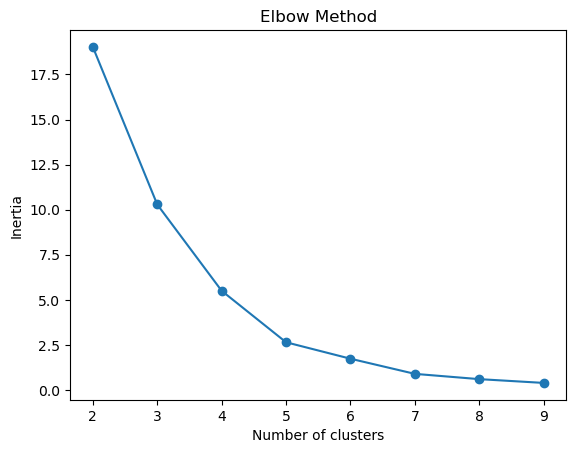

k=2, silhouette score=0.604
k=3, silhouette score=0.571
k=4, silhouette score=0.569
k=5, silhouette score=0.455
k=6, silhouette score=0.422
k=7, silhouette score=0.378
k=8, silhouette score=0.374
k=9, silhouette score=0.319


In [431]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Select features
features = years_pre_COVID_df[['avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal']]

# Aggregate per station 
station_features = features.groupby(years_pre_COVID_df['station_id']).mean()

# Standardize features
scaler = StandardScaler()
station_features_scaled = scaler.fit_transform(station_features)



from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Elbow method: The bend (elbow) is the optimal number of clusters.
inertia = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(station_features_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Optional: silhouette score
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(station_features_scaled)
    score = silhouette_score(station_features_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

# we'll have 3 clusters 

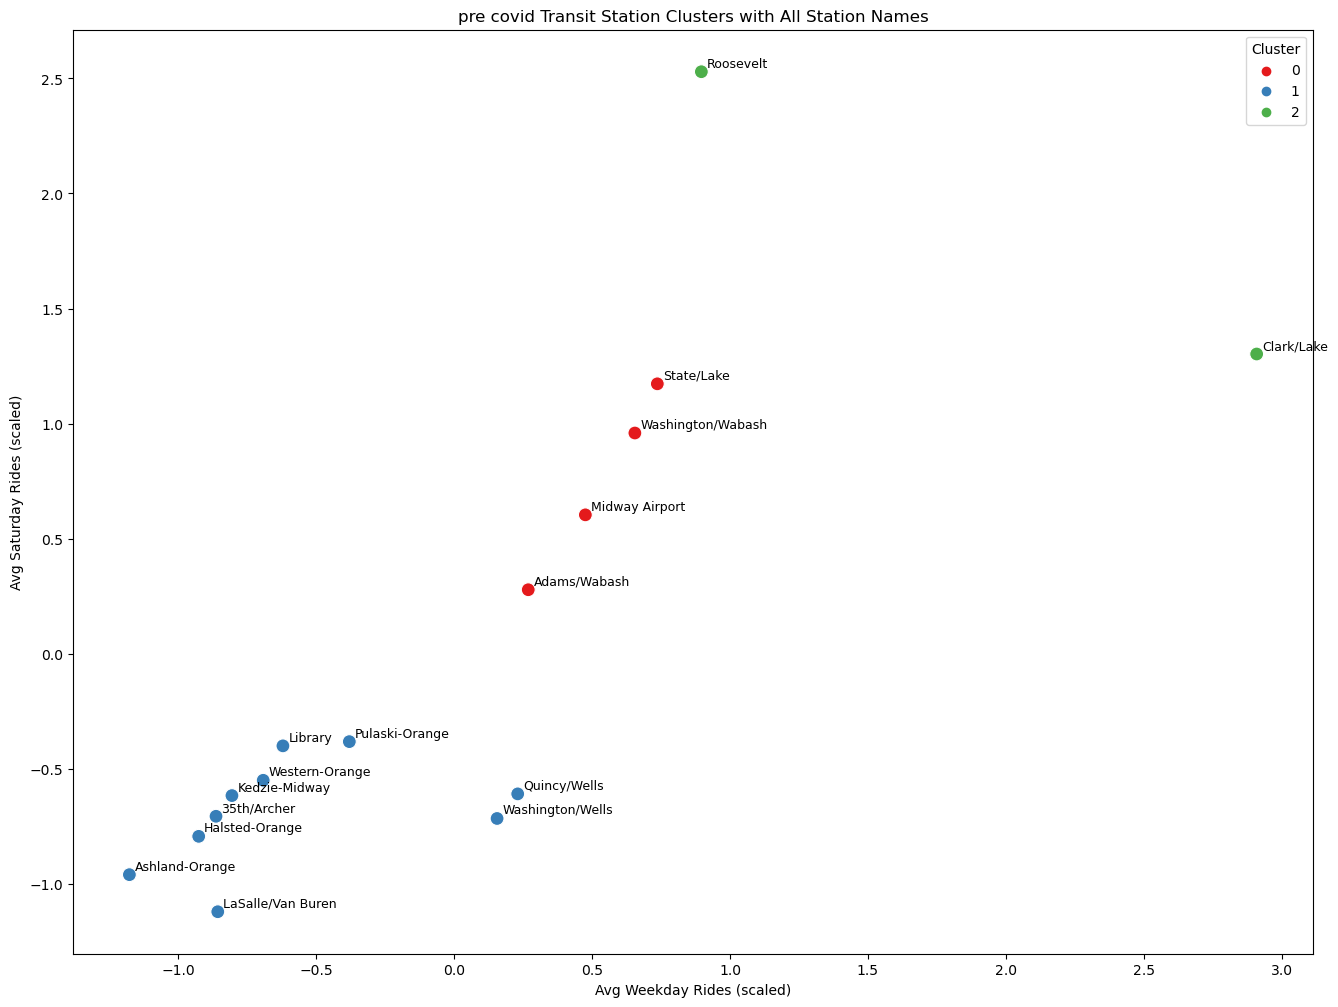

In [442]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- Step 1: Aggregate features per station ---
station_features_numeric = years_pre_COVID_df.groupby('station_id')[[
    'avg_weekday_rides', 'avg_saturday_rides', 'avg_sunday_holiday_rides', 'monthtotal'
]].mean()

station_names = years_pre_COVID_df.groupby('station_id')['stationame'].first()
station_features = station_features_numeric.join(station_names)

# --- Step 2: Scale numeric features ---
scaler = StandardScaler()
station_features_scaled = scaler.fit_transform(station_features[['avg_weekday_rides',
                                                                 'avg_saturday_rides',
                                                                 'avg_sunday_holiday_rides',
                                                                 'monthtotal']])

# --- Step 3: K-means clustering ---
k = 3  # choose number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
station_features['cluster'] = kmeans.fit_predict(station_features_scaled)

# --- Step 4: Prepare DataFrame for plotting ---
plot_df = pd.DataFrame(station_features_scaled,
                       columns=['weekday_scaled', 'saturday_scaled', 'sunday_scaled', 'monthtotal_scaled'],
                       index=station_features.index)
plot_df['cluster'] = station_features['cluster'].values
plot_df['stationame'] = station_features['stationame'].values

# --- Step 5: Scatter plot ---
plt.figure(figsize=(16,12))
sns.scatterplot(
    x='weekday_scaled',
    y='saturday_scaled',
    hue='cluster',
    palette='Set1',
    data=plot_df,
    s=100
)

# --- Step 6: Label all stations ---
for i in range(plot_df.shape[0]):
    plt.text(
        x=plot_df['weekday_scaled'].iloc[i] + 0.02,
        y=plot_df['saturday_scaled'].iloc[i] + 0.02,
        s=plot_df['stationame'].iloc[i],
        fontsize=9
    )

plt.xlabel('Avg Weekday Rides (scaled)')
plt.ylabel('Avg Saturday Rides (scaled)')
plt.title('pre covid Transit Station Clusters with All Station Names')
plt.legend(title='Cluster')
plt.show()

In [441]:
import pandas as pd
import numpy as np

# Assume station_features already has numeric columns and 'cluster' assigned

# --- Step 1: Compute average rides per cluster ---
cluster_summary = station_features.groupby('cluster').agg({
    'avg_weekday_rides': 'mean',
    'avg_saturday_rides': 'mean',
    'avg_sunday_holiday_rides': 'mean',
    'monthtotal': ['mean', 'sum'],  # mean per station and total for cluster
    'stationame': 'count'  # number of stations per cluster
})

# Rename columns for readability
cluster_summary.columns = ['weekday_avg', 'saturday_avg', 'sunday_avg', 'monthtotal_avg', 'monthtotal_sum', 'num_stations']
cluster_summary = cluster_summary.reset_index()

cluster_summary

,cluster,weekday_avg,saturday_avg,sunday_avg,monthtotal_avg,monthtotal_sum,num_stations
0,0,9146.240820,4911.886230,3735.951237,233740.434603,9.349617e+05,4
1,1,4172.232045,1550.357652,1123.966061,100839.083333,1.008391e+06,10
2,2,15183.801894,7627.520076,6068.948106,385329.617424,7.706592e+05,2


 Insight:

* Cluster 1 has many stations but low average, representing small neighborhood stations.

* Cluster 0 has moderate stations and high weekday usage, confirming commuter behavior.

* Cluster 2 has few stations but huge volume, confirming central hubs/high-volume stations.

# Summary: 
###  When looking at riderhsip behavior ('weekday_avg', 'saturday_avg', 'sunday_avg', 'monthtotal_avg', 'monthtotal_sum') for the CTA Orange line from 2008-2018 we see that stations could be segemenated in 3 categories:

 * Cluster 0: Commuter-heavy stations -> high weekday usage, moderate weekend.

 * Cluster 1: Local/low-traffic stations -> low usage all days.

 * Cluster 2: Major hubs -> extremely high usage all days.

This cluster labeling lets you segment stations by function, which is useful for planning, resource allocation, or comparing pre vs post-COVID behavior

# Summary: 
COVID shifted the riderhsip patterns for Orange Line riders. When looking at 2020-2025 ridership data, we can see that ridership has drastiavlly delcined since 2018. Additionally, we see some stations with a considerable drop in their porpotional weekday rides: 
* Clark/Lake was mainly driven by a drop in weekday rides(largest shift)
* 35th/Archer was mainly driven by a drop in weekday rides
* Washington/Wells mainly driven by a drop in weekday rides
* Midway Airport mainly driven by a drop in weekday rides
* LaSalle/Van Buren mainly driven by a drop in weekday rides
* Pulaski-Orange mainly driven by a drop in weekday rides

When comparing k-mean clusters for pre-COVID years (2008-2018) with post-COVID years (2020-2025) we see a shift in ridership behavior at the station level. Post-COVID, we see stations State/Lake and Washiston/Wabash shift up to a cluster with 
* extremely high total ridership
* Strong weekday AND strong weekend traffic
* Likely downtown, transfer, airport, entertainment centers

*This indicates a need for highest staffing, security, maintenance*

We also see that stations Pulaski, Quincy/Wells, and Washinton/Wells shift up to a cluster(Commuter-Dominant Stations) with 
* High weekday traffic
* Moderate weekend traffic
* business district commute flow

*This indicates a need for weekday peak service*


Yes, COVID affected public transit patterns, but not all communities were impacted equally. With this analysis, we can recalibrate service, staffing, and resource allocation to match the new ridership reality. 
**Key takeaways include:**

* High-volume, mixed-use stations (e.g., State/Lake, Washington/Wabash) now experience strong weekday and weekend traffic. These stations likely serve downtown hubs, transfer points, airport connections, or entertainment areas. They require increased staffing, security, and maintenance to handle the consistently high demand.

* Commuter-dominant stations (e.g., Pulaski, Quincy/Wells, Washington/Wells) still see strong weekday traffic but moderate weekend activity. These stations primarily support business district commuting, highlighting the need for weekday peak service optimization.

* Neighborhood or low-traffic stations experienced relatively smaller changes, suggesting that service levels can be maintained or adjusted moderately based on evolving usage patterns.

By combining ridership trends with cluster analysis, transit planners can target resources more efficiently, adapt schedules to shifting demand, and ensure that both commuter and high-traffic hub stations are adequately supported post-COVID. This approach allows the transit system to respond dynamically to changing travel behaviors while maintaining safety and service quality.
